In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250907-mse-to-bt',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])
round_metrics_df.config_name.value_counts()

Loading results for DMSs: {'HSP82_YEAST_Flynn_2019', 'PPM1D_HUMAN_Miller_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'ANCSZ_Hobbs_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'CBS_HUMAN_Sun_2020', 'OXDA_RHOTO_Vanella_2023_activity', 'BLAT_ECOLX_Firnberg_2014', 'SHOC2_HUMAN_Kwon_2022'}


config_name
MLP-BT          540
MLP-MSE         540
Random          540
RandomForest    540
Name: count, dtype: int64

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_31943/2854233526.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


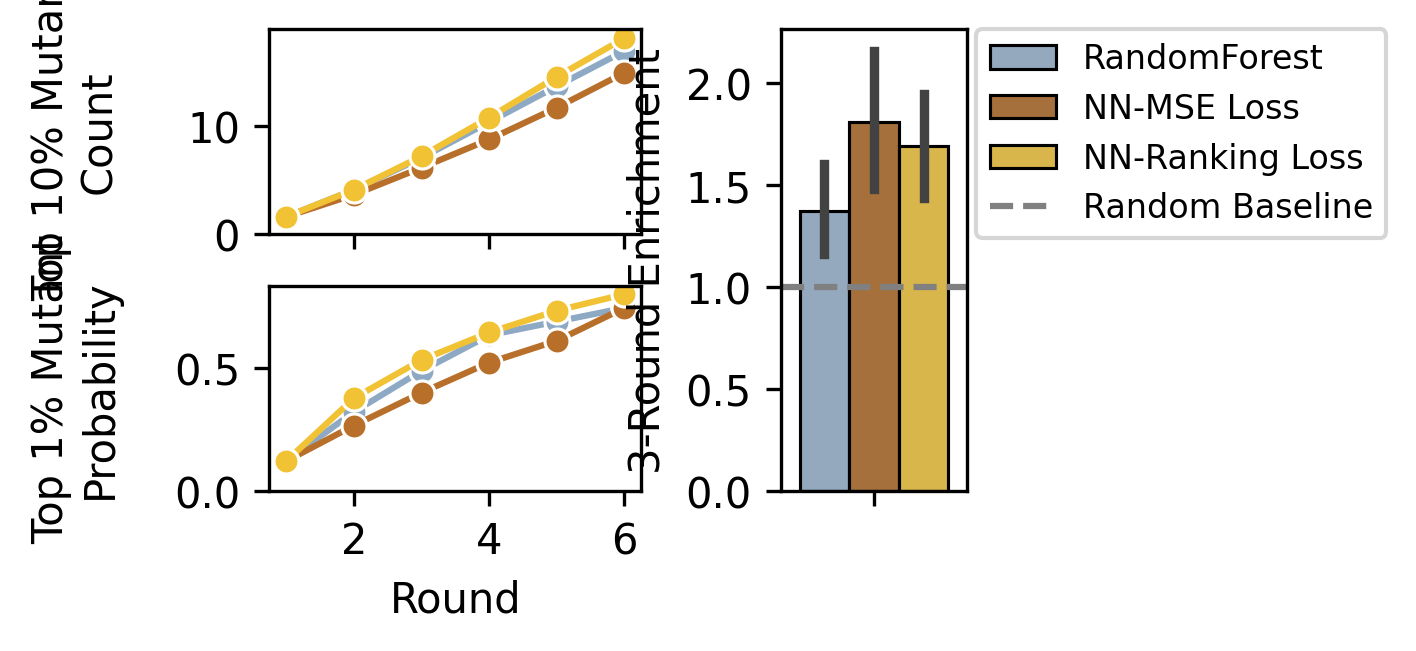

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

CONFIG_MAP = {
    'RandomForest': 'RandomForest',
    'MLP-MSE': 'NN-MSE Loss',
    'MLP-BT': 'NN-Ranking Loss',
}

plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_MAP.keys())].copy()
plot_df['config_name'] = plot_df.config_name.apply(lambda x: CONFIG_MAP[x])
# plot_df['enrichment'] = plot_df.held_out_1pct_recall / 0.01 + plot_df.held_out_10pct_recall / 0.1
plot_df['batch_enrichment'] = (plot_df.held_out_batch_1pct / 0.01 + plot_df.held_out_batch_10pct / 0.1) / 2

# Palette for both charts

# Teal: 2A9D8F
# Pretty light gold: FFE5B4
# Rust / amber: B86F2A
# Plum: 5B4E77
PALETTE = {
    'RandomForest': '#8DA9C4',
    'NN-MSE Loss': '#B86F2A',
    'NN-Ranking Loss': '#F1C233',
}

# Layout: 2 rows (recalls), 2 columns (recall vs enrichment)
fig = plt.figure(figsize=(3, 2), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], wspace=0.5, hspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])  # recall 1%
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)  # recall 10%
ax3 = fig.add_subplot(gs[:, 1])  # enrichment barplot (spans both rows)

# --- Left side: Recall lineplots ---
for ax, metric, ylabel in zip(
    [ax1, ax2],
    ['cumulative_10pct_hits', 'has_found_top_1pct'],
    # ['held_out_batch_1pct', 'held_out_batch_10pct'],
    # ['held_out_1pct_recall', 'held_out_10pct_recall'],
    ['Top 10% Mutant\nCount', 'Top 1% Mutant\nProbability'],
):
    sns.lineplot(
        ax=ax,
        data=plot_df,
        x='round_num',
        y=metric,
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=CONFIG_MAP.values(),
        palette=PALETTE,
        legend=False
    )
    ax.set_ylabel(ylabel)
    # ax.legend_.remove()
    ax.set_ylim(0, ax.get_ylim()[1])

ax1.tick_params(labelbottom=False)  # hide xtick labels on the top chart
ax2.set_xlabel("Round")
ax1.set_xlabel("")  # hide top x-label
ax1.yaxis.set_label_coords(-0.4, 0.5)
ax2.yaxis.set_label_coords(-0.4, 0.5)
ax2.set_xticks([2, 4, 6])

# --- Right side: Enrichment barplot ---
sns.barplot(
    ax=ax3,
    data=plot_df[plot_df.round_num <= 3],
    y='batch_enrichment',
    hue='config_name',
    hue_order=CONFIG_MAP.values(),
    palette=PALETTE,
    edgecolor='black',
    linewidth=0.75,
)
ax3.set_ylabel('3-Round Enrichment')
ax3.axhline(1, color='grey', linewidth=1.5, linestyle='--', label='Random Baseline')
ax3.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=8
)

plt.tight_layout()
plt.show()

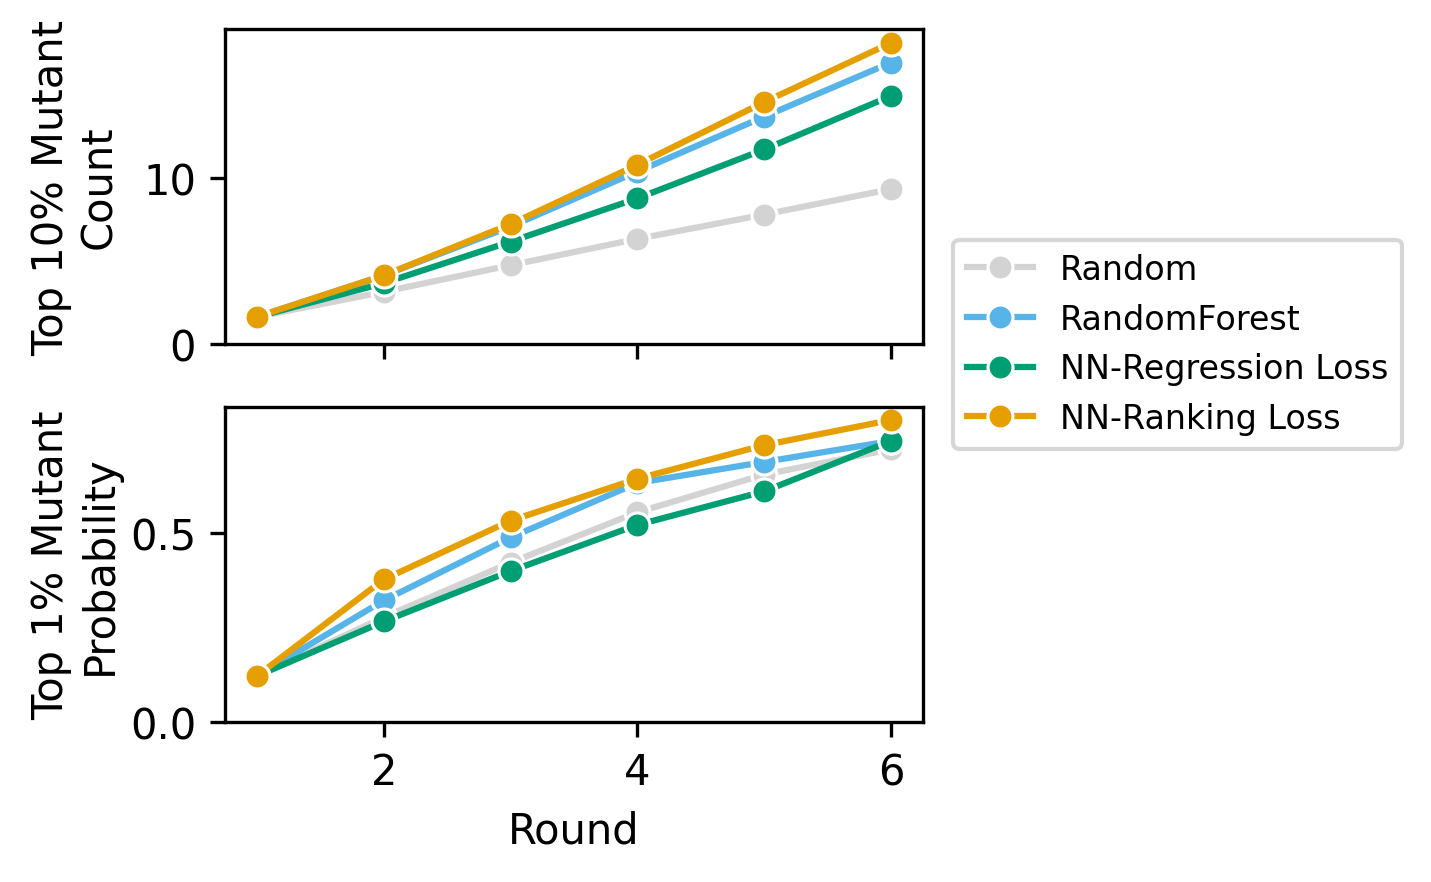

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

CONFIG_MAP = {
    'Random': 'Random',
    'RandomForest': 'RandomForest',
    'MLP-MSE': 'NN-Regression Loss',
    'MLP-BT': 'NN-Ranking Loss',
}

plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIG_MAP.keys())].copy()
plot_df['config_name'] = plot_df.config_name.apply(lambda x: CONFIG_MAP[x])

PALETTE = {
    'NN-Regression Loss': '#009E73',
    'NN-Ranking Loss': '#E69F00',
    'RandomForest': '#56B4E9',
    'Random': 'lightgrey',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), dpi=300, sharex=True)

# Top plot
sns.lineplot(
    ax=ax1,
    data=plot_df,
    x='round_num',
    y='cumulative_10pct_hits',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=list(CONFIG_MAP.values()),
    palette=PALETTE
)
ax1.set_ylabel('Top 10% Mutant\nCount')
ax1.set_ylim(0, ax1.get_ylim()[1])
ax1.set_xlabel('')
ax1.yaxis.set_label_coords(-0.15, 0.5)

# Bottom plot
sns.lineplot(
    ax=ax2,
    data=plot_df,
    x='round_num',
    y='has_found_top_1pct',
    hue='config_name',
    errorbar=None,
    marker='o',
    hue_order=list(CONFIG_MAP.values()),
    palette=PALETTE,
    legend=False
)
ax2.set_ylabel('Top 1% Mutant\nProbability')
ax2.set_ylim(0, ax2.get_ylim()[1])
ax2.set_xlabel('Round')
ax2.set_xticks([2, 4, 6])
ax2.yaxis.set_label_coords(-0.15, 0.5)

# Configure legend - move Random to end and place on right
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0),
    fontsize=8
)

plt.savefig('notebooks/jacob/paperplots/sup_mse_vs_bt.png', dpi=300, bbox_inches='tight')